In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
 roc_auc_score, classification_report,
 confusion_matrix, precision_recall_curve,
 average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
# Load clean data
df = pd.read_csv("../data/loan_clean.csv")
FEATURES = [c for c in df.columns if c != "default"]
X = df[FEATURES]
y = df["default"]
# Stratified split — ensures same default rate in train and test
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.20, # 80% train, 20% test
 random_state=42,
 stratify=y # CRITICAL: maintain class balance in both sets
)
print(f"Train: {X_train.shape} | Default rate: {y_train.mean()*100:.2f}%")
print(f"Test: {X_test.shape} | Default rate: {y_test.mean()*100:.2f}%")

Train: (39600, 20) | Default rate: 40.10%
Test: (9900, 20) | Default rate: 40.10%


In [3]:
# Check imbalance BEFORE SMOTE
print("BEFORE SMOTE:")
print(f"Class 0 (No Default): {(y_train==0).sum()}")
print(f"Class 1 (Default): {(y_train==1).sum()}")
print(f"Ratio: {(y_train==0).sum() / (y_train==1).sum():.1f}:1")
# Apply SMOTE — ONLY on training data, NEVER on test data!
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print("\nAFTER SMOTE:")
print(f"Class 0 (No Default): {(y_train_sm==0).sum()}")
print(f"Class 1 (Default): {(y_train_sm==1).sum()}")
print("Classes are now balanced 50:50")


BEFORE SMOTE:
Class 0 (No Default): 23721
Class 1 (Default): 15879
Ratio: 1.5:1

AFTER SMOTE:
Class 0 (No Default): 23721
Class 1 (Default): 23721
Classes are now balanced 50:50


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# ✅ Scale data (IMPORTANT for Logistic Regression)
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# ■■ Logistic Regression ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
print('Training Logistic Regression...')

lr = LogisticRegression(max_iter=3000, random_state=42, C=0.1)

lr.fit(X_train_sm_scaled, y_train_sm)

lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)

print(f'Logistic Regression AUC: {lr_auc:.4f}')


# ■■ Random Forest ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
print('\nTraining Random Forest...')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print(f'Random Forest AUC: {rf_auc:.4f}')


# ■■ XGBoost ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
print('\nTraining XGBoost...')

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_sm,
    y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f'XGBoost AUC: {xgb_auc:.4f}')


# ■■ Comparison table ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [lr_auc, rf_auc, xgb_auc]
})

print('\n=== MODEL COMPARISON ===')
print(results.sort_values('AUC-ROC', ascending=False).to_string(index=False))

Training Logistic Regression...
Logistic Regression AUC: 0.5096

Training Random Forest...
Random Forest AUC: 0.5009

Training XGBoost...
[0]	validation_0-auc:0.50743
[50]	validation_0-auc:0.50438
[100]	validation_0-auc:0.50241
[150]	validation_0-auc:0.50139
[200]	validation_0-auc:0.50039
[250]	validation_0-auc:0.49843
[300]	validation_0-auc:0.49775
[350]	validation_0-auc:0.49690
[400]	validation_0-auc:0.49615
[450]	validation_0-auc:0.49500
[499]	validation_0-auc:0.49527
XGBoost AUC: 0.4953

=== MODEL COMPARISON ===
              Model  AUC-ROC
Logistic Regression 0.509553
      Random Forest 0.500928
            XGBoost 0.495268


In [5]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
 "n_estimators": [200, 300, 400, 500],
 "max_depth": [4, 5, 6, 7, 8],
 "learning_rate": [0.01, 0.05, 0.08, 0.1],
 "subsample": [0.7, 0.8, 0.9, 1.0],
 "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
 "min_child_weight": [1, 3, 5],
 "gamma": [0, 0.1, 0.2, 0.3],
}
# NOTE: do NOT include use_label_encoder — removed in XGBoost >= 1.6
xgb_base = XGBClassifier(eval_metric="auc", random_state=42, n_jobs=-1)
search = RandomizedSearchCV(
 xgb_base,
 param_distributions=param_dist,
 n_iter=30, # Try 30 random combinations
 cv=5, # 5-fold cross validation
 scoring="roc_auc", # Optimize for AUC
 random_state=42,
 n_jobs=-1,
 verbose=2
)
search.fit(X_train_sm, y_train_sm)
print("Best Parameters:", search.best_params_)
print("Best CV AUC:", search.best_score_)
# Final model with best hyperparameters
best_model = search.best_estimator_
final_proba = best_model.predict_proba(X_test)[:,1]
final_auc = roc_auc_score(y_test, final_proba)
print(f"\nFinal Tuned Model AUC: {final_auc:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}
Best CV AUC: 0.6529383169151248

Final Tuned Model AUC: 0.4910


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Default       0.59      0.66      0.62      5930
     Default       0.39      0.33      0.36      3970

    accuracy                           0.53      9900
   macro avg       0.49      0.49      0.49      9900
weighted avg       0.51      0.53      0.52      9900



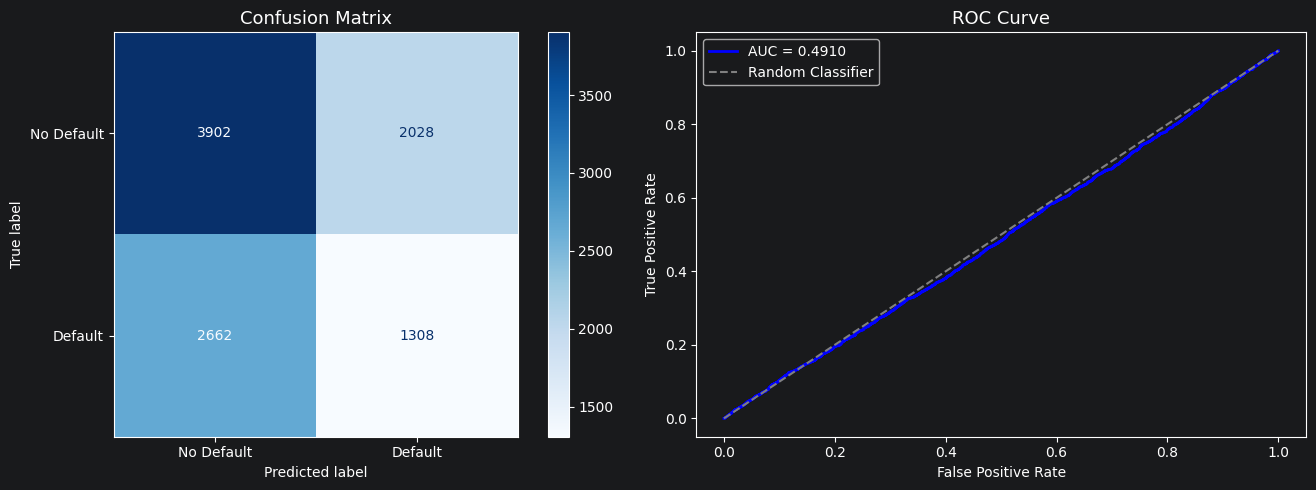


BUSINESS METRICS:
True Positives (defaulters caught): 1308
False Positives (good customers rejected): 2028
False Negatives (defaulters missed): 2662
Precision: 39.2% of flagged are real defaults
Recall: 32.9% of all defaults caught


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
y_pred = best_model.predict(X_test)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred,
 target_names=["No Default", "Default"]))
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
 y_test, y_pred,
 display_labels=["No Default", "Default"],
 cmap="Blues", ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontsize=13)
fpr, tpr, _ = roc_curve(y_test, final_proba)
axes[1].plot(fpr, tpr, color="blue", lw=2, label=f"AUC = {final_auc:.4f}")
axes[1].plot([0,1],[0,1],"--", color="gray", label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13)
axes[1].legend()
plt.tight_layout()
plt.savefig("../plots/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
# Business-level metrics
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nBUSINESS METRICS:")
print(f"True Positives (defaulters caught): {tp}")
print(f"False Positives (good customers rejected): {fp}")
print(f"False Negatives (defaulters missed): {fn}")
print(f"Precision: {tp/(tp+fp)*100:.1f}% of flagged are real defaults")
print(f"Recall: {tp/(tp+fn)*100:.1f}% of all defaults caught")

In [14]:
import math
def probability_to_credit_score(pd_probability, base_score=600, pdo=20):
 """
 Convert default probability to credit score (300-900).
 Uses the PDO (Points to Double Odds) industry-standard method.
 Args:
 pd_probability: float 0-1 (e.g. 0.15 = 15% chance of default)
 base_score: int score at 50-50 odds (default 600)
 pdo: int points to double odds (default 20)
 Returns:
 credit_score: int clamped to 300-900
 """
 # Clamp to avoid log(0) or log(infinity)
 pd_probability = max(min(pd_probability, 0.999), 0.001)
 # Odds = P(repay) / P(default)
 odds = (1 - pd_probability) / pd_probability
 # PDO formula
 score = base_score + pdo * math.log2(odds)
 # Clamp to 300-900 range (CIBIL-style)
 return int(max(300, min(900, round(score))))
def get_credit_decision(score):
 """Translate credit score to approve / review / reject."""
 if score >= 700:
     return "AUTO APPROVE", "GREEN", "Low risk — auto disburse loan"
 elif score >= 500:
     return "MANUAL REVIEW", "AMBER", "Medium risk — human review needed"
 else:
     return "AUTO REJECT", "RED", "High risk — loan declined"
# Test the scorecard
test_cases = [0.02, 0.10, 0.25, 0.50, 0.75, 0.90]
print("PD Probability -> Credit Score -> Decision")
print("-" * 55)
for pd_val in test_cases:
 score = probability_to_credit_score(pd_val)
 decision, color, reason = get_credit_decision(score)
 print(f"PD={pd_val*100:>5.0f}% Score={score} {decision:15} {reason}")


PD Probability -> Credit Score -> Decision
-------------------------------------------------------
PD=    2% Score=712 AUTO APPROVE    Low risk — auto disburse loan
PD=   10% Score=663 MANUAL REVIEW   Medium risk — human review needed
PD=   25% Score=632 MANUAL REVIEW   Medium risk — human review needed
PD=   50% Score=600 MANUAL REVIEW   Medium risk — human review needed
PD=   75% Score=568 MANUAL REVIEW   Medium risk — human review needed
PD=   90% Score=537 MANUAL REVIEW   Medium risk — human review needed


Score Distribution:
decision
MANUAL REVIEW    9900
Name: count, dtype: int64

Approval rate: 0.0 %
Review rate:  100.0 %
Reject rate:  0.0 %


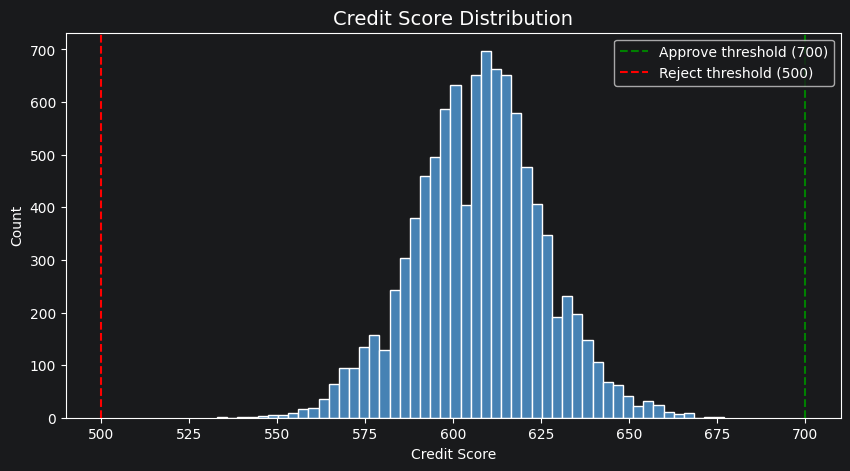

In [15]:
# Apply scorecard to the full test set
test_scores = [probability_to_credit_score(p) for p in final_proba]
test_decisions = [get_credit_decision(s)[0] for s in test_scores]
results_df = pd.DataFrame({
 "default_prob": final_proba.round(4),
 "credit_score": test_scores,
 "decision": test_decisions,
 "actual": y_test.values
})
print("Score Distribution:")
print(results_df["decision"].value_counts())
print()
print("Approval rate:", (results_df["decision"] == "AUTO APPROVE").mean() * 100, "%")
print("Review rate: ", (results_df["decision"] == "MANUAL REVIEW").mean() * 100, "%")
print("Reject rate: ", (results_df["decision"] == "AUTO REJECT").mean() * 100, "%")
# Score distribution plot
plt.figure(figsize=(10, 5))
plt.hist(test_scores, bins=50, color="steelblue", edgecolor="white")
plt.axvline(700, color="green", linestyle="--", label="Approve threshold (700)")
plt.axvline(500, color="red", linestyle="--", label="Reject threshold (500)")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.title("Credit Score Distribution", fontsize=14)
plt.legend()
plt.savefig("../plots/score_distribution.png", dpi=150, bbox_inches="tight")

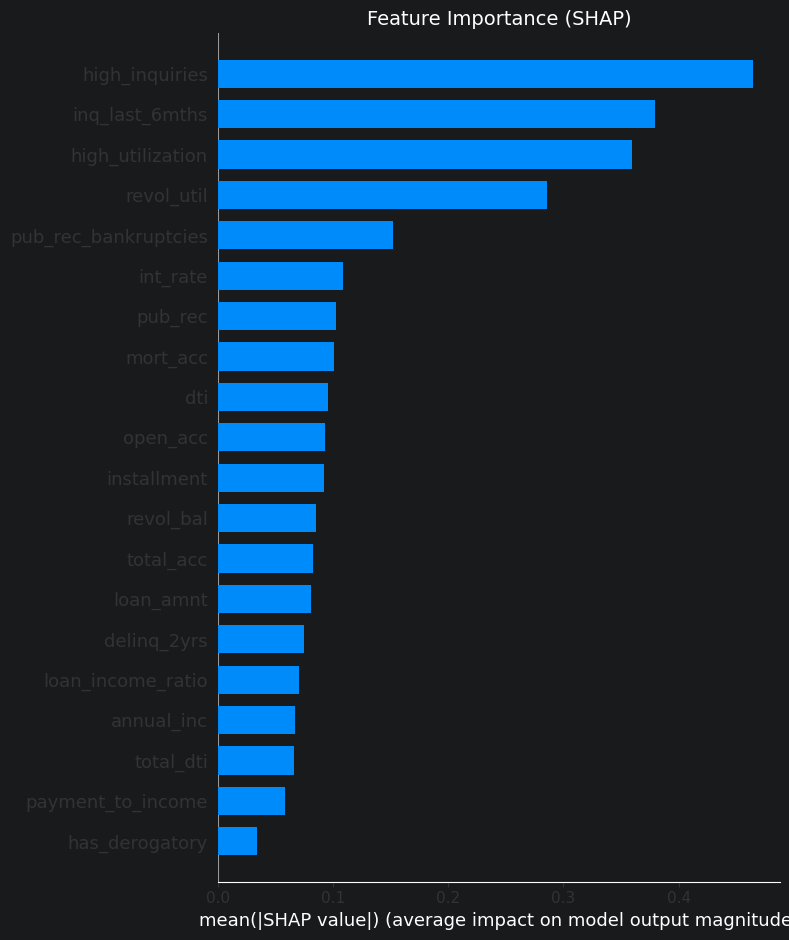

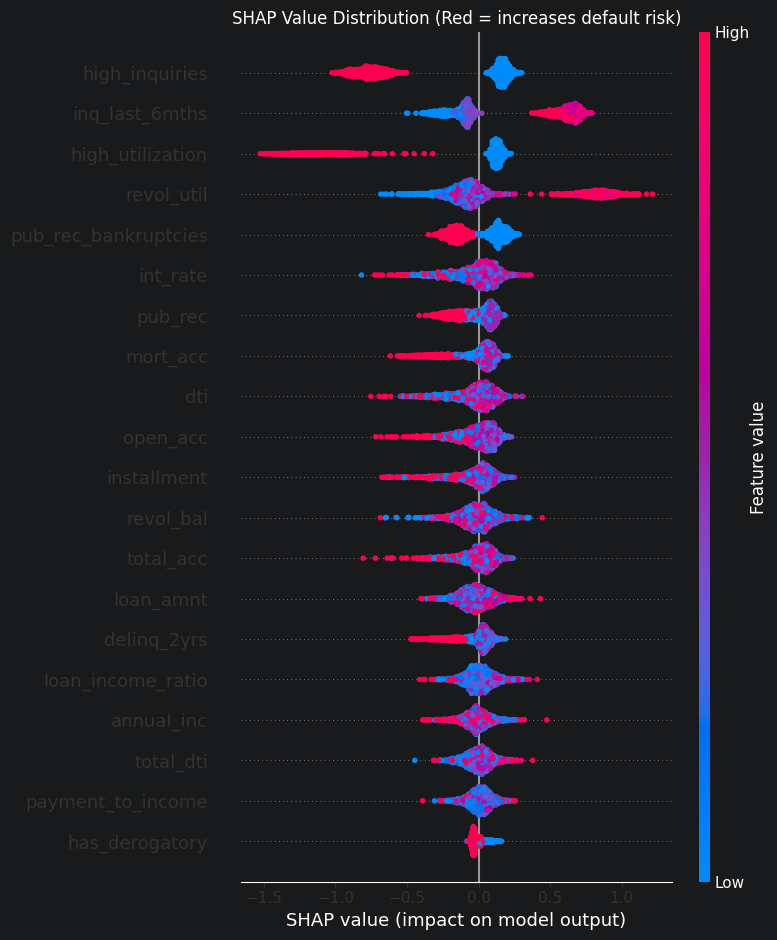

In [18]:
import shap
import matplotlib.pyplot as plt

# TreeExplainer is optimised for XGBoost / tree-based models
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values on 2000 test samples (full dataset takes too long)
X_sample = X_test.iloc[:2000]

# ✅ FIX: SHAP new versions return Explanation object
shap_values = explainer(X_sample)

# Plot 1: Bar chart — features ranked by mean absolute SHAP value
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES,
                  show=False, plot_type="bar")
plt.title("Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("../plots/shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Dot plot — shows direction and magnitude of each feature
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False)
plt.title("SHAP Value Distribution (Red = increases default risk)", fontsize=12)
plt.tight_layout()
plt.savefig("../plots/shap_dot.png", dpi=150, bbox_inches="tight")
plt.show()

No AUTO REJECT cases found. Using first available customer instead.


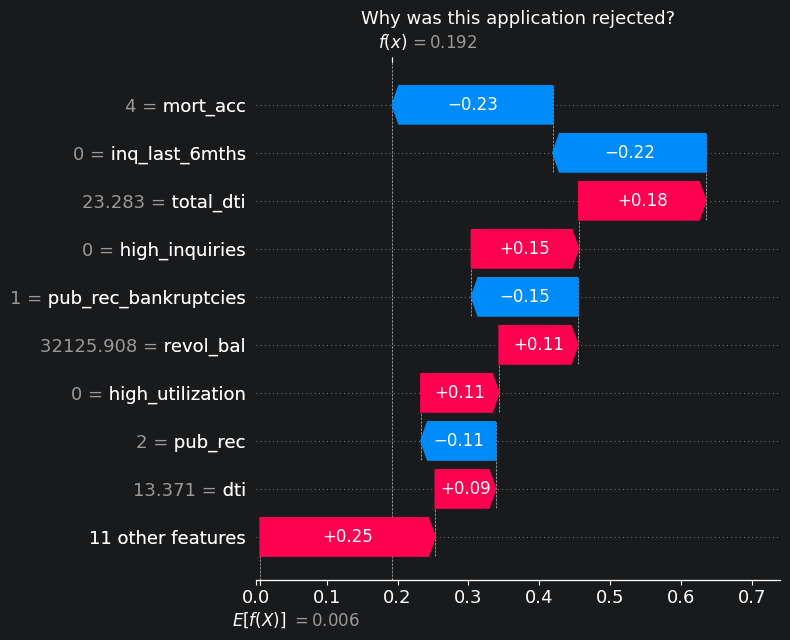

<Figure size 1000x400 with 0 Axes>

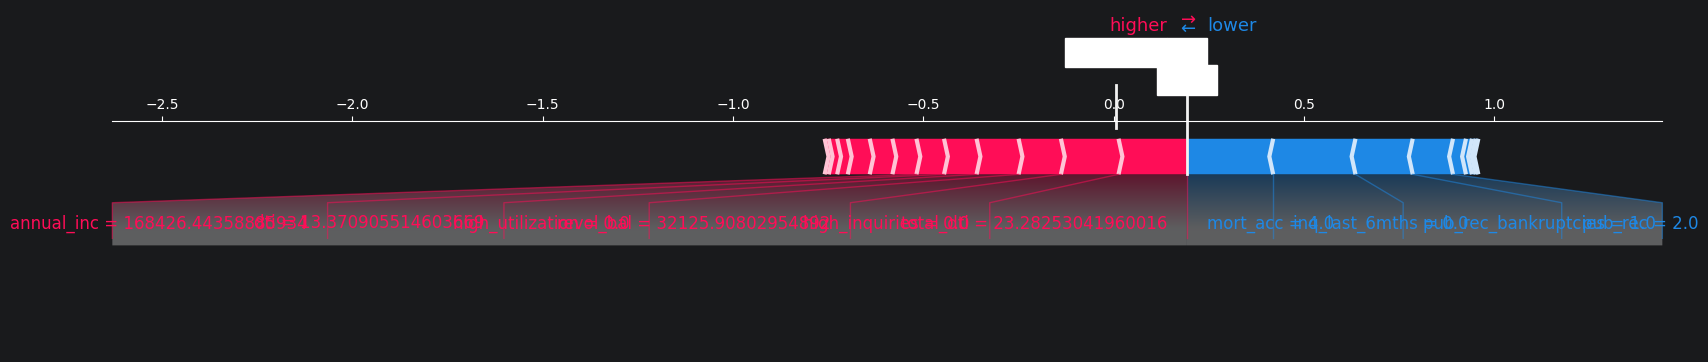

TOP 5 REASONS FOR REJECTION:
mort_acc: DECREASES default risk by 0.2266
inq_last_6mths: DECREASES default risk by 0.2162
total_dti: INCREASES default risk by 0.1796
high_inquiries: INCREASES default risk by 0.1514
pub_rec_bankruptcies: DECREASES default risk by 0.1504


In [25]:
import matplotlib.pyplot as plt
import shap

# Pick a rejected customer to explain why
rejected_rows = results_df[results_df["decision"] == "AUTO REJECT"]

if len(rejected_rows) == 0:
    print("No AUTO REJECT cases found. Using first available customer instead.")
    customer_idx = 0
else:
    customer_idx = rejected_rows.index[0]  # use position directly

# SHAP values for this one customer
single_shap = explainer(X_test.iloc[[customer_idx]])

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.waterfall_plot(single_shap[0], show=False)
plt.title("Why was this application rejected?", fontsize=13)
plt.tight_layout()
plt.savefig("../plots/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

# Force plot
plt.figure(figsize=(10, 4))
shap.plots.force(single_shap[0], matplotlib=True, show=False)
plt.savefig("../plots/shap_force.png", dpi=150, bbox_inches="tight")
plt.show()

# Generate plain-text explanation
feature_contribs = list(zip(FEATURES, single_shap.values[0]))
feature_contribs.sort(key=lambda x: abs(x[1]), reverse=True)

print("TOP 5 REASONS FOR REJECTION:")
for feat, val in feature_contribs[:5]:
    direction = "INCREASES" if val > 0 else "DECREASES"
    print(f"{feat}: {direction} default risk by {abs(val):.4f}")

In [1]:
import joblib
import json
import os

# ✅ Ensure models folder exists
os.makedirs("../models", exist_ok=True)

# Save trained model
joblib.dump(best_model, "../models/credit_model.pkl")
print("Model saved: ../models/credit_model.pkl")

# Save feature list — API must use the EXACT same feature order
with open("../models/feature_names.json", "w") as f:
    json.dump(FEATURES, f)
print("Features saved: ../models/feature_names.json")

# Save performance metrics for the Streamlit dashboard
metrics = {
    "auc_roc": round(final_auc, 4),
    "precision": round(float((results_df["decision"] == "AUTO APPROVE").mean()), 4),
    "best_params": str(search.best_params_) if 'search' in globals() else "N/A",
    "training_samples": len(X_train_sm),
    "test_samples": len(X_test),
    "default_rate": round(float(y.mean()), 4)
}

with open("../models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved: ../models/metrics.json")

# Verify all files exist
for fname in os.listdir("../models"):
    size = os.path.getsize(f"../models/{fname}") / 1024
    print(f"{fname}: {size:.1f} KB")

NameError: name 'best_model' is not defined